In [2]:
import quimb as qu
import quimb.tensor as qtn
import numpy as np
import re
import networkx as nx
import matplotlib.pyplot as plt
from collections import defaultdict
print('done')

c:\Users\titou\miniforge3\envs\projetqte\Lib\site-packages\cotengra\hyperoptimizers\hyper.py:39: UserWarning: Couldn't import `kahypar` - skipping from default hyper optimizer and using basic `labels` method instead.
  warnings.warn(


done


# Circuit generation

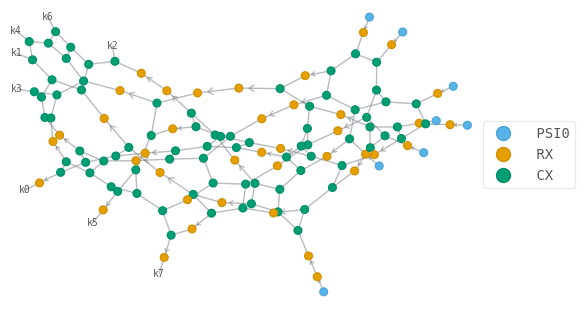

<Circuit(n=8, num_gates=80, gate_opts={'contract': 'auto-split-gate', 'propagate_tags': 'register'})>


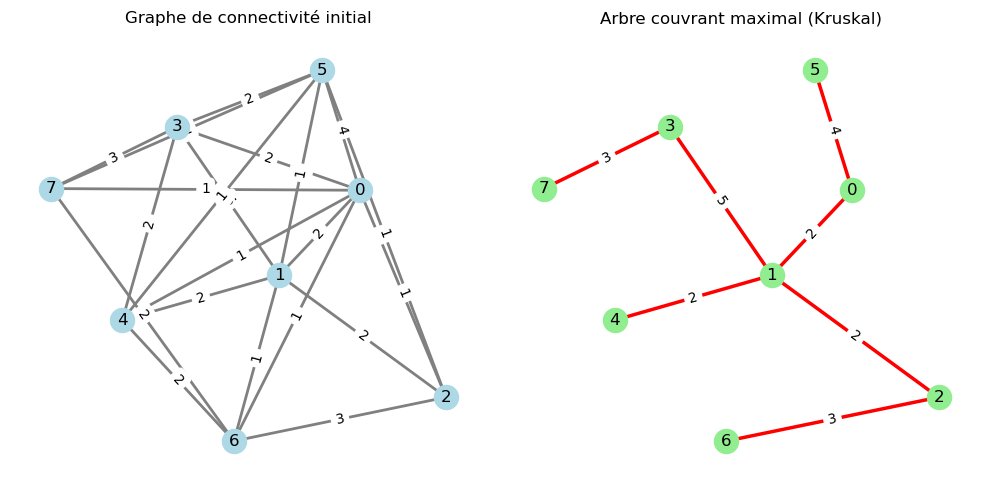

In [ ]:
num_qubits = 15
num_layers = 10
seed = 47

def generate_semi_random_entangled_circuits(num_qubits, num_layers, seed = None, plot = False):
    ## 1ere idée : faire des circuits quantiques aléatoires intriqués fortement
    rng = np.random.default_rng(seed=seed)
    angles = 2 * np.pi * rng.random((num_layers, num_qubits))
    print(angles)

    # besoin du nombre de couche, de la seed du random 
    circ = qtn.Circuit(N=num_qubits)

    for i in range(num_layers) : 
        for qubit in range(num_qubits):
        ##rotations aléatoires sur les qubits de manière non aléatoires
            circ.rx(theta=angles[i][qubit], i=qubit)
        
        ##cnot sur les adjacents maintenant
        for qubit in range(num_qubits) : 
            circ.cnot(qubit, (qubit+1)%num_qubits)
            if qubit == 0 : 
                circ.cnot(qubit, (qubit+1)%num_qubits)


    if plot : 
        circ.psi.draw(color=['PSI0', 'RX', 'CX'])

    print(circ)
    return circ


#circuit = generate_semi_random_entangled_circuits(num_qubits=num_qubits, num_layers=num_layers)

def plot_connectivity_and_max_mst(circ, return_adjacency_matrix=False, plot = True):

    G = nx.Graph()
    edge_weights = defaultdict(int)

    for gate in circ.gates:
        if len(gate.qubits) == 2:
            q1, q2 = sorted(gate.qubits)
            edge_weights[(q1, q2)] += 1

    for (q1, q2), weight in edge_weights.items():
        G.add_edge(q1, q2, weight=weight)

    mst = nx.maximum_spanning_tree(G, weight="weight", algorithm="kruskal")
    pos = nx.spring_layout(G, seed=42)

    if plot : 
            
        # --- Affichage des graphes ---
        plt.figure(figsize=(10, 5))

        # Graphe original
        plt.subplot(1, 2, 1)
        nx.draw(G, pos, with_labels=True, node_color="lightblue", edge_color="gray", width=2)
        nx.draw_networkx_edge_labels(G, pos, edge_labels=nx.get_edge_attributes(G, "weight"))
        plt.title("Graphe de connectivité initial")

        # Arbre couvrant maximal
        plt.subplot(1, 2, 2)
        nx.draw(mst, pos, with_labels=True, node_color="lightgreen", edge_color="red", width=2.5)
        nx.draw_networkx_edge_labels(mst, pos, edge_labels=nx.get_edge_attributes(mst, "weight"))
        plt.title("Arbre couvrant maximal (Kruskal)")

        plt.tight_layout()
        plt.show()

    # --- Matrice d’adjacence (optionnelle) ---
    if return_adjacency_matrix:
        # Tri pour garantir l'ordre canonique des nœuds
        ordered_nodes = sorted(G.nodes)
        adj_matrix = mst.to_numpy_array(G, nodelist=ordered_nodes, weight='weight')
        return G, mst, adj_matrix

    return G, mst

#G, mst, adj = plot_connectivity_and_max_mst(circuit, return_adjacency_matrix=True)
#print("Matrice d'adjacence pondérée :\n", adj)


def generate_random_entangled_circuits(num_qubits, num_layers, seed1=None, seed2=None, plot=False):

    # --- Génération des angles RX ---
    rng_angles = np.random.default_rng(seed=seed1)
    angles = 2 * np.pi * rng_angles.random((num_layers, num_qubits))

    # --- Génération des couples CNOT (ctrl ≠ tgt) ---
    rng_cnots = np.random.default_rng(seed=seed2)
    total_needed = num_layers * num_qubits
    pairs = []

    while len(pairs) < total_needed:
        raw = rng_cnots.integers(0, num_qubits, size=(total_needed * 2, 2))
        # Supprimer les cas où ctrl == tgt
        filtered = [tuple(p) for p in raw if p[0] != p[1]]
        pairs.extend(filtered)

    # Réorganiser par couches
    cnot_pairs = [
        pairs[i * num_qubits:(i + 1) * num_qubits]
        for i in range(num_layers)
    ]

    # --- Construction du circuit ---
    circ = qtn.Circuit(N=num_qubits)

    for i in range(num_layers):
        for qubit in range(num_qubits):
            circ.rx(theta=angles[i][qubit], i=qubit)

        for ctrl, tgt in cnot_pairs[i]:
            circ.cnot(ctrl, tgt)

    # --- Affichage optionnel ---
    if plot:
        circ.psi.draw(color=['PSI0', 'RX', 'CX'])

    print(circ)
    return circ


circ = generate_random_entangled_circuits(
    num_qubits=8,
    num_layers=5,
    seed1=123,
    seed2=453,
    plot=True
)

G, mst, adj = plot_connectivity_and_max_mst(circ, return_adjacency_matrix=True)

# Tree generation

In [7]:
class Tree:
    def __init__(self,root = None,matrix = None,max_bond = None,cutoff = None):
        self.nodes = {}
        self.network = None
        self.neutral = root
        self.root = root

        self.nodes[root.index] = root
        self.network = root.tensor
        self.cutoff = cutoff
        self.max_bond = max_bond

        ####### utile dans les autres fonc
    
    def to_str(self,node):
        return ''.join(node)

    def to_list(self,node):
        return re.findall(r'[A-Za-z]|\d+', node)

    def diff_part_str(self,A,B):
        A = self.to_list(A)
        B = self.to_list(B)

        prefix = []

        for i in range(min(len(A),len(B))):
            if A[i] == B[i]:
                prefix.append(A[i])
            else:
                break

        if not(prefix[-1].isnumeric()):
            prefix.pop()
        return prefix,A[len(prefix):],B[len(prefix):]

    def get_previous_node(self,node):
        nb = int(node[-1])
        if nb == 1:
            return node[0:-2]
        else:
            return node[0:-1]+[str(nb-1)]

    def is_adjacent(self,i,j):
        i = self.to_list(i)
        j = self.to_list(j)
        if self.get_previous_node(i) == j or self.get_previous_node(j) == i:
            return True
        else:
            return False

    def get_path_to_last_common_node(self,node,last_common_node):

        path = []
        
        previous_node = node
        while previous_node != last_common_node:
            path.append(self.to_str(previous_node))
            previous_node = self.get_previous_node(previous_node)

        path.append(self.to_str(last_common_node))
        return path

    def get_path(self,A,B):
        last_common_node,tail_A,tail_B = self.diff_part_str(A,B)

        A_to_lcn = list(reversed(self.get_path_to_last_common_node(self.to_list(A),last_common_node)))
        B_to_lcn = list(reversed(self.get_path_to_last_common_node(self.to_list(B),last_common_node)))


        for i in range(min(len(A_to_lcn),len(B_to_lcn))):
            if A_to_lcn[i] != B_to_lcn[i]:
                return list(reversed(A_to_lcn[i-1:]))+B_to_lcn[i:]
        return list(reversed(A_to_lcn[i+1:]))+B_to_lcn[i:]

    def swap_adjacent(self,i,j):
        # print('swapping ',i,j)
        array = np.array([[1,0,0,0],[0,0,1,0],[0,1,0,0],[0,0,0,1]],dtype=float).reshape(2,2,2,2)
        self.apply_2qb_gate(i,j,gate_array = array)

    ###### methodes

    def shift_neutral(self,i,j,side = 'right'):

        # print('called shift_neutral on ',i,j)

        if not(self.is_adjacent(i,j)):
            raise Exception('not adjacent')
        
        # get nodes
        node_1 = self.nodes[i]
        node_2 = self.nodes[j]
        # get indexes
        side_1 = list(node_1.tensor.inds)
        side_2 = list(node_2.tensor.inds)
        # print('1',side_1)
        # print('2',side_2)
        # print('nodes',node_1.tensor,node_2.tensor)

        bond_ind = (set(node_1.tensor.inds) & set(node_2.tensor.inds)).pop()
        side_1.remove(bond_ind)
        side_2.remove(bond_ind)

        # print(bond_ind)
        # print(side_1)
        # print(side_2)

        # 'apply' gate
        contracted_qubits = node_1.tensor @ node_2.tensor

        split_tensor = contracted_qubits.split(left_inds=side_1,right_inds=side_2,method='svd',absorb=side,bond_ind=bond_ind,max_bond=self.max_bond, cutoff=self.cutoff)
        
        ind_1 = split_tensor.ind_map[side_1[0]].pop()
        tensor_1 = split_tensor.tensor_map[ind_1]
        ind_2 = split_tensor.ind_map[side_2[0]].pop()
        tensor_2 = split_tensor.tensor_map[ind_2]

        tensor_1.drop_tags([j])
        tensor_2.drop_tags([i])

        result = tensor_1 & tensor_2
        node_1.tensor = tensor_1
        node_2.tensor = tensor_2

        self.network.delete(i)
        self.network.delete(j)

        self.network = self.network & node_1.tensor
        self.network = self.network & node_2.tensor

    def shift_along_path(self,node,root):
        path = self.get_path(node,root)
        # print('shifting along ',path)
        
        for i in range(len(path)-1):
            self.shift_neutral(path[i],path[i+1],side = 'right')

    def add(self,node):
        self.nodes[node.index] = node

        if self.network == None:
            self.network = node.tensor
        else:
            self.network = self.network & node.tensor

        if node.up is not None:
            self.nodes[node.up].add_child(node.index)

        Id = np.array([[1,0,0,0],[0,0,1,0],[0,1,0,0],[0,0,0,1]],dtype=float).reshape(2,2,2,2)
        self.apply_2qb_gate(i = node.index,j = node.up,gate_array=Id,already_linked=False)
        #canonalize
        self.shift_along_path(node.index,self.root.index)

    def apply_1qb_gate(self,i,gate_array = np.array([[1,0],[0,1]],dtype = complex)):
        node = self.nodes[i]
        gate = qtn.Tensor(data=gate_array,inds = ['out'+i,'nout'+i],tags = ['gate'])
        nqubit = self.network[i] & gate
        nqubit.contract_ind('out'+i)
        nqubit.reindex_({'nout'+i:'out'+i})
        nqubit.drop_tags('gate')

        node.tensor = nqubit[i]

        self.network.delete(i)

        self.network = self.network & nqubit

    def apply_2qb_gate(self,i,j,gate_array = np.array([[1,0,0,0],[0,1,0,0],[0,0,1,0],[0,0,0,1]],dtype=float).reshape(2,2,2,2),side = 'right',already_linked=True):
        # print('called apply 2qb gate on ',i,j)
        # self.draw()
        swapped = False
        if not(self.is_adjacent(i,j)):
            # print('not adjacent,swapping')
            # raise Exception('not adjacent')
            path = self.get_path(i,j)
            for k in range(len(path)-2):
                self.swap_adjacent(path[k],path[k+1])
            old_i = i
            i = path[k+1]
            # print('--- swapping non adjacent over')
            swapped = True

        def sort_indexes(i,j):
            if len(i) > len(j):
                return i,j
            elif len(i) < len(j):
                return j,i
            elif int(i[-1]) > int(j[-1]):
                return i,j
            else:
                return j,i
        
        farthest_ind,closest_ind = sort_indexes(i,j)

        if already_linked:
            # print('shifting neutral to',i)
            self.shift_along_path(self.root.index,farthest_ind)
            # print('--- shifting neutral to ',i,' over')
            # self.draw()
            # print('before applying gate')
        
        # print('applying gate to',i,j)
        # get nodes
        node_1 = self.nodes[i]
        node_2 = self.nodes[j]

        #define gate
        gate = qtn.Tensor(data=gate_array,inds = ['out'+i,'out'+j,'nout'+i,'nout'+j],tags = ['gate'])

        if already_linked:
            bond_ind = j+'-'+i+'b'
        else:
            bond_ind = j+'-'+i

        #change indexes to match gate indexes

        gate = gate.split(left_inds=['out'+i,'nout'+i],method='svd',absorb='both',bond_ind=bond_ind)#,max_bond=self.max_bond, cutoff=self.cutoff)

        # 'apply' gate
        qubits = node_1.tensor & node_2.tensor
        qubits_and_gate = qubits & gate
        qubits_and_gate.contract_ind('out'+i)
        qubits_and_gate.contract_ind('out'+j)

        qu.tensor.tensor_fuse_squeeze(qubits_and_gate[i],qubits_and_gate[j])

        qubits_and_gate.reindex_({'nout'+i:'out'+i,'nout'+j:'out'+j})
        qubits_and_gate.drop_tags('gate')

        node_1.tensor = qubits_and_gate[i]
        node_2.tensor = qubits_and_gate[j]

        self.network.delete(i)
        self.network.delete(j)

        self.network = self.network & qubits_and_gate
        # print('gate applied on ',i,j)
        # self.draw()
        # print('after applying gate')

        if swapped:
            # print('swapping back')
            for k in range(1,len(path)-1):
                # print(k)
                self.swap_adjacent(path[:-1][-k],path[:-1][-k-1])
            # print('--- swapping back over')

        if already_linked:
            # print('putting neutral back to root from ',i)
            self.shift_along_path(farthest_ind,self.root.index)
        # print('draw after last shift')
        # self.draw()
        
    def draw(self):
        return self.network.draw(show_tags=True, show_inds='all',iterations=100, k=6)

    def swap(self,A,B):
        path = self.get_path(A,B)
        for i in range(len(path)-1):
            self.swap_adjacent(path[i],path[i+1])

    def nb_coef(self):
        nb = 0
        for tensor in self.network:
            nb += np.prod(tensor.shape)
        return nb

class Node:
    def __init__(self,index,up,childrens = []):#,up_bdim,childrens_bdim):
        self.index = index
        self.up = up
        # self.childrens = childrens
        self.childrens = []
        # self.up_bdim = up_bdim
        # self.childrens_bdim = childrens_bdim
        self.init_tensor()
    
    def init_tensor(self):
        self.tensor = qtn.Tensor(data=np.array([1,0],dtype=complex),inds=['out'+self.index],tags = [self.index])

    def add_child(self,index):
        # print('added child ',index,' to ',self.index)
        self.childrens.append(index)

    def reindex(self,dic):
        self.tensor.reindex_(dic)

        for i in dic.keys():
            if self.up == i:
                self.up = dic[i]
            if i in self.childrens:
                self.childrens.remove(i)
                self.childrens.append(dic[i])


def tree_from_matrix(matrix,root):
    R0 = Node(index='R0',up = None)
    tree = Tree(R0)

    trad_dic = {0:'R0'}

    #parcours d'arbre
    queue = []
    marked = []

    queue.append(root)
    marked.append(root)

    # print('-------------------------')
    # print('queue :',queue)
    # print('marked :',marked)
    # print('current dic :',trad_dic)

    while len(queue) > 0:
        # print('-------------------------')
        # print('queue :',queue)
        # print('marked :',marked)
        # print('current dic :',trad_dic)

        index = queue.pop(0)

        #todo/action on node
        # print('popped ',index)

        #ajoute les enfants de index à la queue
        enfants = [i for i in range(len(matrix[index])) if (matrix[index][i] != 0) and (i not in marked)]
        nb_enfants = len(enfants)
        # print('enfants :',enfants)

        for i in enfants:
            # print('child :',i)
            if i not in marked:
                # print('not marked')
                queue.append(i)
                marked.append(i)

                #create Node
                if nb_enfants == 1:
                    # print(index,' has one child')
                    node_index = trad_dic[index][:-1]+str(int(trad_dic[index][-1])+1)
                if nb_enfants > 1:
                    # print(index,' has ',nb_enfants,' childrens')
                    node_index = trad_dic[index] + chr(ord('@')+enfants.index(i)+1)+str(1)
                node = Node(index=node_index,up=trad_dic[index])
                tree.add(node)
                # print('added node with index ',node_index,' and parent ',trad_dic[index],' to tree')

                # print('parent ',trad_dic[index])
                # print(' current child ',node_index)

                trad_dic[i] = node_index

    return tree


# Both

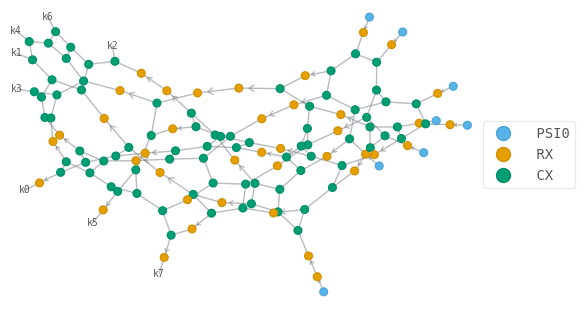

<Circuit(n=8, num_gates=80, gate_opts={'contract': 'auto-split-gate', 'propagate_tags': 'register'})>


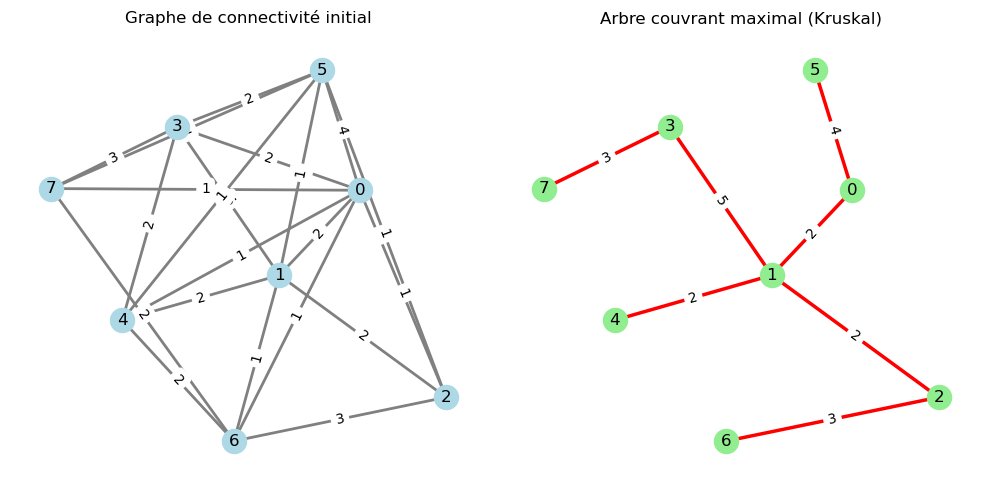

In [5]:
circ = generate_random_entangled_circuits(
    num_qubits=8,
    num_layers=5,
    seed1=123,
    seed2=453,
    plot=True
)

G, mst, adj = plot_connectivity_and_max_mst(circ, return_adjacency_matrix=True)

In [8]:
adj

array([[0., 2., 1., 2., 1., 4., 1., 1.],
       [2., 0., 2., 5., 2., 1., 1., 0.],
       [1., 2., 0., 0., 0., 1., 3., 0.],
       [2., 5., 0., 0., 2., 2., 0., 3.],
       [1., 2., 0., 2., 0., 1., 2., 0.],
       [4., 1., 1., 2., 1., 0., 0., 1.],
       [1., 1., 3., 0., 2., 0., 0., 2.],
       [1., 0., 0., 3., 0., 1., 2., 0.]])

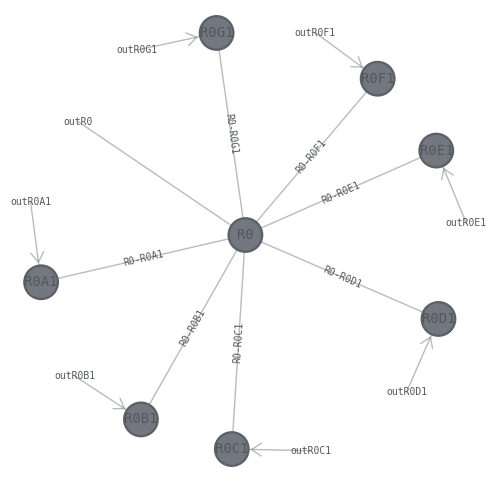

In [10]:
tree = tree_from_matrix(adj,0)
tree.draw()